<a href="https://colab.research.google.com/github/nishad-dev/Sales-Analyzing-bot-/blob/main/Copy_of_app.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install streamlit pandas matplotlib scikit-learn openpyxl

In [ ]:
!pip install streamlit pyngrok openpyxl

In [ ]:
from pyngrok import ngrok

ngrok.set_auth_token("3DO0lIOE3tfQX188DxFu7fpPvlj_4u9JaFhQHSJtJwobDfQgP")

In [ ]:
from pyngrok import ngrok

ngrok.set_auth_token("3DO0lIOE3tfQX188DxFu7fpPvlj_4u9JaFhQHSJtJwobDfQgP")

In [ ]:
%%writefile app.ipynb

Writing app.ipynb


In [ ]:
!streamlit run app.ipynb &>/content/logs.txt &

In [ ]:
public_url = ngrok.connect(8501)

print(public_url)

NgrokTunnel: "https://yelling-mundane-astride.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
!pip install openpyxl --quiet

Mounted at /content/drive
Enter file path: /content/drive/MyDrive/Nike Dataset.csv
Dataset Loaded Successfully

Available Columns:
['Invoice Date', 'Product', 'Region', 'Retailer', 'Sales Method', 'State', 'Price per Unit', 'Total Sales', 'Units Sold']

Cleaned Dataset Shape: (9356, 10)

PRODUCT CODES


,Product Code,Product Name
0,MSF001,Men's Street Footwear
1,MAF002,Men's Athletic Footwear
2,WSF003,Women's Street Footwear
3,WAF004,Women's Athletic Footwear
4,MAP005,Men's Apparel
5,WAP006,Women's Apparel



TOP PRODUCTS


,Total Sales
Product,
Men's Street Footwear,1999192
Women's Apparel,1720630
Men's Athletic Footwear,1468116
Women's Street Footwear,1224756
Men's Apparel,1192682



REGION PERFORMANCE


,Total Sales
Region,
West,2329193
Northeast,1863429
Southeast,1631786
South,1446722
Midwest,1358145



MONTHLY SALES


,Total Sales
Month,
1,693202
2,585601
3,548289
4,703079
5,777973
6,704135
7,906328
8,880349
9,747984


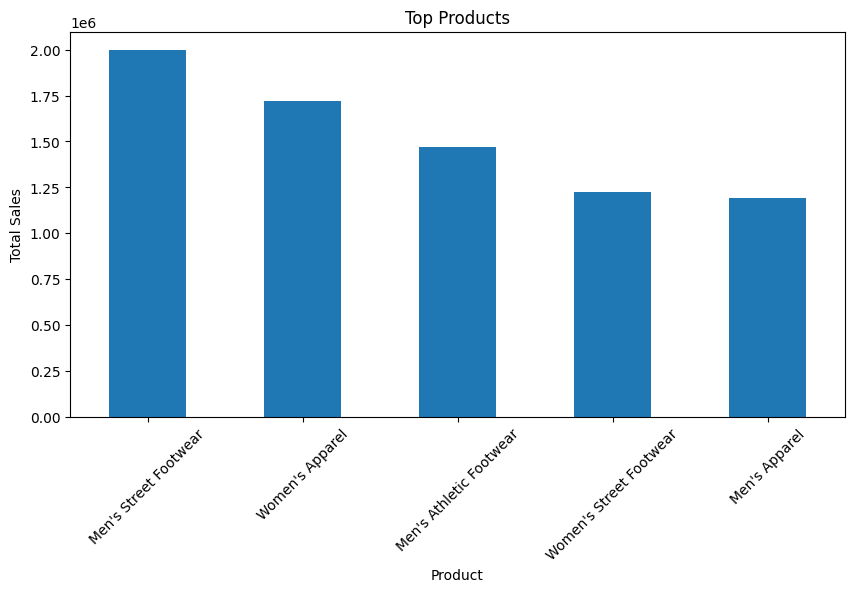

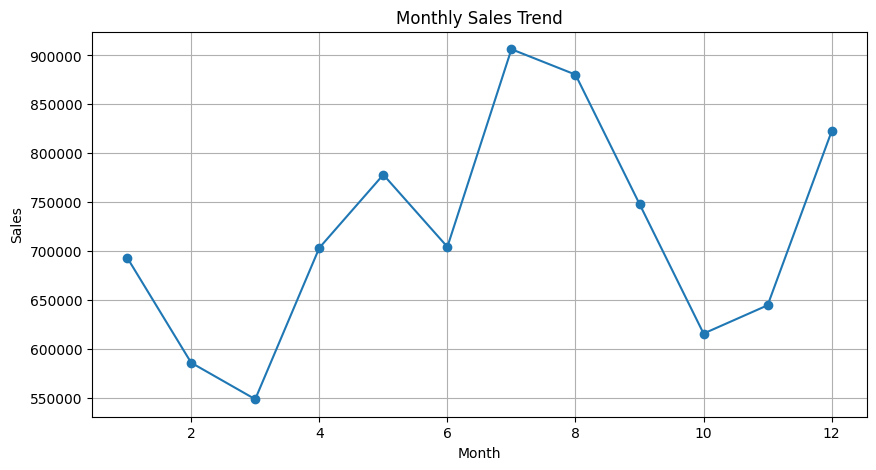


AVAILABLE PRODUCTS


,Product Code,Product Name
0,MSF001,Men's Street Footwear
1,MAF002,Men's Athletic Footwear
2,WSF003,Women's Street Footwear
3,WAF004,Women's Athletic Footwear
4,MAP005,Men's Apparel
5,WAP006,Women's Apparel


In [ ]:
# AI RETAIL SALES BOT - UPDATED GOOGLE COLAB VERSION  MAIN CODE

# INSTALL LIBRARY
!pip install openpyxl --quiet

# IMPORT LIBRARIES
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# MOUNT GOOGLE DRIVE
drive.mount('/content/drive')

# FILE PATH
file_path = input("Enter file path: ")

# READ DATA
if file_path.endswith('.csv'):
    df = pd.read_csv(file_path)
else:
    df = pd.read_excel(file_path)

print("Dataset Loaded Successfully")

# =========================
# COLUMN CLEANING
# =========================

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Convert all column names to consistent format
df.columns = df.columns.str.replace('_', ' ')

print("\nAvailable Columns:")
print(df.columns.tolist())

# =========================
# DATE CLEANING
# =========================

# Convert Invoice Date safely
df['Invoice Date'] = pd.to_datetime(
    df['Invoice Date'],
    errors='coerce',
    dayfirst=True
)

# Remove invalid dates
df = df.dropna(subset=['Invoice Date'])

# EXTRACT MONTH
df['Month'] = df['Invoice Date'].dt.month

# =========================
# DATA CLEANING
# =========================

# Remove invalid rows
df = df[
    (df['Units Sold'] > 0) &
    (df['Price per Unit'] > 0) &
    (df['Total Sales'] > 0)
]

# Remove duplicates
df = df.drop_duplicates()

print("\nCleaned Dataset Shape:", df.shape)

# =========================
# PRODUCT CODES
# =========================

prefixes = {
    "Men's Street Footwear": "MSF",
    "Men's Athletic Footwear": "MAF",
    "Women's Street Footwear": "WSF",
    "Women's Athletic Footwear": "WAF",
    "Men's Apparel": "MAP",
    "Women's Apparel": "WAP"
}

product_codes = {}

for i, product in enumerate(df['Product'].unique()):

    prefix = prefixes.get(product, "PRD")

    product_codes[f"{prefix}{i+1:03}"] = product

# PRODUCT TABLE
product_df = pd.DataFrame({
    "Product Code": list(product_codes.keys()),
    "Product Name": list(product_codes.values())
})

print("\nPRODUCT CODES")
display(product_df)

# =========================
# QUICK ANALYSIS
# =========================

top_products = (
    df.groupby('Product')['Total Sales']
    .sum()
    .sort_values(ascending=False)
)

region_sales = (
    df.groupby('Region')['Total Sales']
    .sum()
    .sort_values(ascending=False)
)

monthly_sales = (
    df.groupby('Month')['Total Sales']
    .sum()
    .sort_index()
)

print("\nTOP PRODUCTS")
display(top_products.head())

print("\nREGION PERFORMANCE")
display(region_sales)

print("\nMONTHLY SALES")
display(monthly_sales)

# =========================
# TOP PRODUCTS CHART
# =========================

plt.figure(figsize=(10,5))

top_products.head().plot(kind='bar')

plt.title("Top Products")
plt.xlabel("Product")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()

# =========================
# MONTHLY SALES CHART
# =========================

plt.figure(figsize=(10,5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker='o'
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

# =========================
# USER INPUTS
# =========================

print("\nAVAILABLE PRODUCTS")
display(product_df)

selected_code = input("Enter Product Code: ").strip()

# Validate Product Code
if selected_code not in product_codes:

    print("Invalid Product Code")

else:

    units_sold = int(input("Enter Units Sold: "))

    selected_month = int(input("Enter Month (1-12): "))

    selected_product = product_codes[selected_code]

    print("\nSelected Product:", selected_product)

    # FILTER PRODUCT DATA
    product_data = df[
        df['Product'] == selected_product
    ]

    # =========================
    # REGION ANALYSIS
    # =========================

    region_analysis = (
        product_data.groupby('Region')['Total Sales']
        .sum()
    )

    highest_region = region_analysis.idxmax()

    lowest_region = region_analysis.idxmin()

    # =========================
    # MONTH ANALYSIS
    # =========================

    monthly_product_sales = (
        product_data.groupby('Month')['Total Sales']
        .sum()
        .sort_index()
    )

    best_month = monthly_product_sales.idxmax()

    weak_month = monthly_product_sales.idxmin()

    # =========================
    # EXPECTED REVENUE
    # =========================

    avg_price = product_data['Price per Unit'].mean()

    expected_revenue = units_sold * avg_price

    # =========================
    # SEASON DETECTION
    # =========================

    if selected_month in [11, 12]:

        season = "Christmas & Winter Season"

    elif selected_month in [6, 7, 8]:

        season = "Summer Vacation Season"

    else:

        season = "Regular Sales Season"

    # =========================
    # RESULTS
    # =========================

    print("\n===== SALES INSIGHTS =====")

    print("Highest Sales Region:", highest_region)

    print("Lowest Sales Region:", lowest_region)

    print("Expected Revenue:",
          format(expected_revenue, ",.2f"))

    print("Best Sales Month:", best_month)

    print("Weak Sales Month:", weak_month)

    print("Season:", season)

    # =========================
    # PRODUCT SALES CHART
    # =========================

    plt.figure(figsize=(10,5))

    plt.plot(
        monthly_product_sales.index,
        monthly_product_sales.values,
        marker='o'
    )

    plt.title(f"Monthly Sales - {selected_product}")

    plt.xlabel("Month")

    plt.ylabel("Sales")

    plt.grid(True)

    plt.show()

    # =========================
    # MACHINE LEARNING
    # =========================

    X = product_data[
        ['Units Sold', 'Price per Unit', 'Month']
    ]

    y = product_data['Total Sales']

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    model = LinearRegression()

    model.fit(X_train, y_train)

    prediction = model.predict([
        [units_sold, avg_price, selected_month]
    ])

    print("\nPredicted Sales:",
          format(prediction[0], ",.2f"))

    # =========================
    # BUSINESS RECOMMENDATIONS
    # =========================

    print("\n===== BUSINESS RECOMMENDATIONS =====")

    print(f"1. {highest_region} region shows strong demand.")

    print(f"2. {lowest_region} region needs improvement.")

    print(f"3. Month {best_month} gives highest sales.")

    print(f"4. Month {weak_month} may require promotions.")

    print(f"5. Focus marketing during {season}.")